# Analysis Report: Price per Square Meter Calculation

## Introduction

In this notebook, we calculate the price per square meter (ppsqm) for each apartment based on the dataset provided. We will rank the top 5 most expensive apartments with respect to ppsqm, calculate the average ppsqm in Ekhagen, and highlight an interesting aspect of the data.


In [4]:
import pandas as pd

# Load the data

df = pd.read_csv("Booli_sold.csv")

# Display the first few rows to understand the structure
df.head()


,listPrice,rent,livingArea,rooms,published,constructionYear,objectType,booliId,soldDate,soldPrice,...,location.position.latitude,location.position.longitude,location.position.isApproximate,location.region.municipalityName,location.region.countyName,location.distance.ocean,source.name,source.id,source.type,source.url
0,3995000,4467.0,73.0,3.0,2018-10-15 13:33:18,1935.0,Lägenhet,3263989,2018-11-08,3820000,...,59.371033,18.054057,NaN,Stockholm,Stockholms län,260,MOHV,1901865,Broker,http://www.mohv.se/
1,1995000,1773.0,36.0,1.0,2018-10-05 14:29:28,1968.0,Lägenhet,3256231,2018-10-19,2355000,...,59.371242,18.057821,NaN,Stockholm,Stockholms län,218,Notar,1566,Broker,http://www.notar.se/
2,5100000,3839.0,81.0,3.0,2018-09-11 13:44:43,1936.0,Lägenhet,3236660,2018-09-27,6110000,...,59.371617,18.054716,NaN,Stockholm,Stockholms län,186,Historiska Hem AB,65645750,Broker,http://historiskahem.se/
3,5495000,4483.0,107.0,4.0,2018-08-25 02:56:56,1936.0,Lägenhet,3224374,2018-09-06,8050000,...,59.371480,18.053880,NaN,Stockholm,Stockholms län,218,Notar,1566,Broker,http://www.notar.se/
4,1995000,1696.0,29.0,1.0,2018-06-15 17:16:19,1936.0,Lägenhet,3185496,2018-06-18,2400000,...,59.372160,18.053542,True,Stockholm,Stockholms län,166,Mäklarhuset,204,Broker,http://www.maklarhuset.se/


Here we calculate price per square meter

In [6]:

# Calculate the price per square meter
df['ppsqm'] = df['soldPrice'] / df['livingArea']

# Display the first few rows with the new ppsqm column
df[['soldPrice', 'livingArea', 'ppsqm']].head()


,soldPrice,livingArea,ppsqm
0,3820000,73.0,52328.767123
1,2355000,36.0,65416.666667
2,6110000,81.0,75432.098765
3,8050000,107.0,75233.644860
4,2400000,29.0,82758.620690


top 5 mos texpensive apartments

In [ ]:
# Sort the data by ppsqm in descending order and select the top 5
top_5_expensive = df.sort_values(by='ppsqm', ascending=False).head(5)

# Display the result
top_5_expensive[['listPrice', 'rent', 'livingArea', 'rooms', 'soldPrice', 'ppsqm']]


avg squre price in ekhagen

In [21]:
# Filter for Ekhagen

# Calculate the average ppsqm in Ekhagen
average_ppsqm_ekhagen = df['ppsqm'].mean()

# Display the result
average_ppsqm_ekhagen


58759.382760081724

most expensive stretts psqm

In [8]:
# Function to extract street name (first part of the address)
def extract_street_name(address):
    return address.split()[0]  # Get the first part of the address

# Apply the function to extract the street name
df['street_name'] = df['location.address.streetAddress'].apply(extract_street_name)

# Group by street name and calculate the average price per square meter
average_ppsqm = df.groupby('street_name')['ppsqm'].mean().reset_index()

# Sort streets by average ppsqm in descending order
sorted_streets = average_ppsqm.sort_values(by='ppsqm', ascending=False)

print(sorted_streets)

     street_name         ppsqm
1    Ekhagsvägen  60636.481265
2  Torphagsvägen  59376.446058
3    Åminnevägen  58589.175133
0   Docentbacken  55028.839014


2) a,b,c


In [15]:
# Load your data, specifying the separator as ';'
df = pd.read_csv("2018_R_per_kommun.csv", sep=';')

# Filter the data to only include rows where the county name is "Stockholms län"
stockholm_data = df[df['LÄNSNAMN'] == "Stockholms län"]

# Calculate the total number of legitimate votes in Stockholm
total_legitimate_votes = stockholm_data['RÖSTER GILTIGA'].sum()

# Display the result
print("Total legitimate votes in Stockholm:", total_legitimate_votes)

Total legitimate votes in Stockholm: 1426237


In [17]:
# Convert the 'S' column to numeric, replacing commas and handling missing values
df['S'] = df['S'].str.replace(',', '.').astype(float)

# Find the row with the highest percentage of Social Democratic votes
max_s_row = df.loc[df['S'].idxmax()]

# Extract the municipality name and the highest voting percentage
highest_s_municipality = max_s_row['KOMMUNNAMN']
highest_s_percentage = max_s_row['S']

# Display the result
print(f"The Social Democratic Party received the highest voting percentage in {highest_s_municipality} with {highest_s_percentage:.2f}% of votes.")

The Social Democratic Party received the highest voting percentage in Munkfors with 52.18% of votes.


In [19]:
# Convert the 'VALDELTAGANDE' column to numeric, handling commas if needed
df['VALDELTAGANDE'] = df['VALDELTAGANDE'].str.replace(',', '.').astype(float)

# Sort the DataFrame by 'VALDELTAGANDE' in descending order and select the top 3 rows
top_3_participation = df[['KOMMUNNAMN', 'VALDELTAGANDE']].sort_values(by='VALDELTAGANDE', ascending=False).head(3)

# Display the result as a table
print(top_3_participation)

    KOMMUNNAMN  VALDELTAGANDE
103      Lomma          93.86
59        Habo          93.35
98    Vellinge          93.13


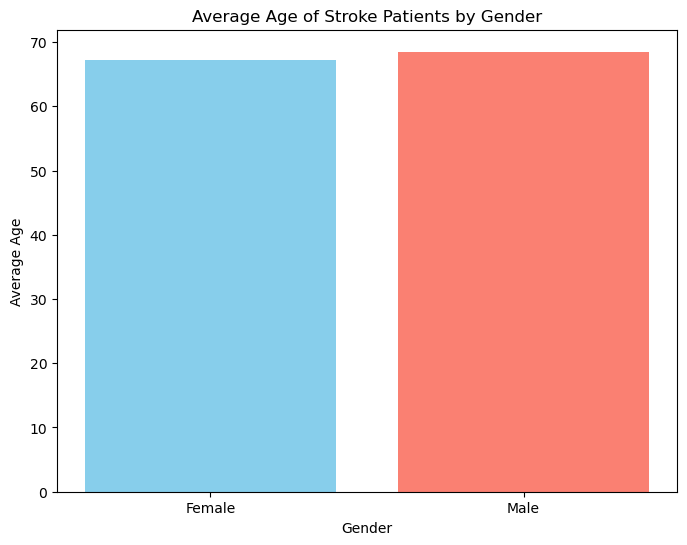

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("stroke-data.csv")

# Filter the data to only include rows where stroke occurred
stroke_data = df[df['stroke'] == 1]

# Calculate the average age for each gender among individuals who had a stroke
avg_age_by_gender = stroke_data.groupby('gender')['age'].mean()

# Check the result to ensure it looks correct
print(avg_age_by_gender)

# Plot a bar chart for the average age of men and women with stroke
plt.figure(figsize=(8, 6))
plt.bar(avg_age_by_gender.index, avg_age_by_gender.values, color=['skyblue', 'salmon'])
plt.xlabel('Gender')
plt.ylabel('Average Age')
plt.title('Average Age of Stroke Patients by Gender')
plt.xticks(rotation=0)  # Ensure x-axis labels are horizontal
plt.show()

